# Capítulo 6 — Nuvens: laboratório numérico

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

| Caso | O que fazemos | Ferramenta |
|---|---|---|
| 1 | diagrama de mistura: bafo e contrail sobre $e_s(T)$ | NumPy |
| 2 | nevoeiro de radiação como EDO: forma e dissipa | `scipy.solve_ivp` |
| 3 | **nuvens fractais**: síntese espectral + contagem de caixas | NumPy/FFT |
| 4 | espaçamento de nuvens de onda e ruas de cumulus | NumPy |

Exercícios numéricos N1–N4 no fim; soluções em `cap06_solucoes.ipynb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

e0, T00, Lv, Rv = 0.6113, 273.15, 2.5e6, 461.0   # Clausius-Clapeyron (Cap. 4)
rho, Cp, g = 1.2, 1004.0, 9.8

def es_kPa(T_C):
    with np.errstate(over='ignore'):
        return e0*np.exp((Lv/Rv)*(1/T00 - 1/(np.asarray(T_C) + T00)))

## Caso 1 — Nuvens de mistura: o bafo e o contrail

Misturar duas massas de ar percorre a **corda** no plano $(T, e)$; a curva $e_s(T)$ é **convexa** — a corda pode passar por cima da curva, e a mistura satura mesmo que os dois ingredientes estejam subsaturados. É o único jeito de fazer nuvem *esquentando* o ar.

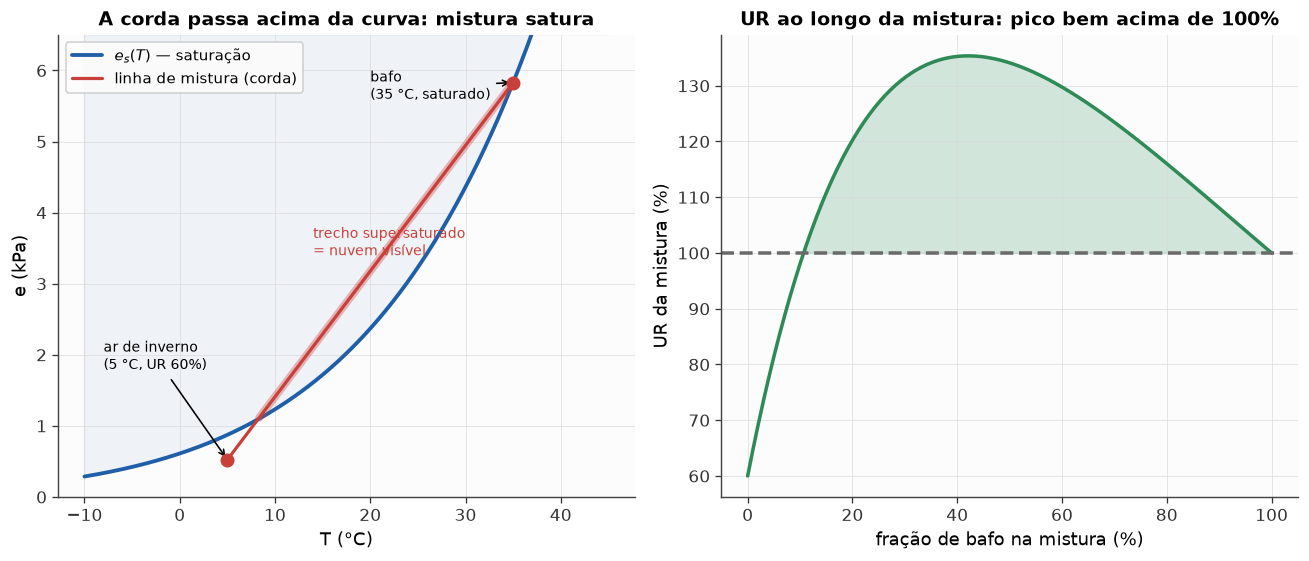

UR máxima da mistura: 135% (na fração de bafo 42%)


In [2]:
T_plot = np.linspace(-10, 45, 300)

# bafo (35 °C saturado) + inverno (5 °C, UR 60%)
T1, e1 = 35.0, es_kPa(35.0)
T2, e2 = 5.0, 0.60*es_kPa(5.0)
f = np.linspace(0, 1, 100)
T_mix, e_mix = f*T1 + (1-f)*T2, f*e1 + (1-f)*e2
UR_mix = 100*e_mix/es_kPa(T_mix)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5))
ax1.plot(T_plot, es_kPa(T_plot), color=CORES['azul'], lw=2.4,
         label='$e_s(T)$ — saturação')
ax1.fill_between(T_plot, es_kPa(T_plot), 6.5, color=CORES['azul'], alpha=0.06)
ax1.plot(T_mix, e_mix, color=CORES['vermelho'], lw=2,
         label='linha de mistura (corda)')
sup = e_mix > es_kPa(T_mix)
ax1.plot(T_mix[sup], e_mix[sup], color=CORES['vermelho'], lw=5, alpha=0.35)
ax1.scatter([T1, T2], [e1, e2], s=60, color=CORES['vermelho'], zorder=5)
ax1.annotate('bafo\n(35 °C, saturado)', xy=(T1, e1), xytext=(20, 5.6),
             fontsize=9, arrowprops=dict(arrowstyle='->', lw=1))
ax1.annotate('ar de inverno\n(5 °C, UR 60%)', xy=(T2, e2), xytext=(-8, 1.8),
             fontsize=9, arrowprops=dict(arrowstyle='->', lw=1))
ax1.text(14, 3.4, 'trecho supersaturado\n= nuvem visível', fontsize=9,
         color=CORES['vermelho'])
ax1.set(xlabel='T (°C)', ylabel='e (kPa)', ylim=(0, 6.5),
        title='A corda passa acima da curva: mistura satura')
ax1.legend(loc='upper left')

ax2.plot(100*f, UR_mix, color=CORES['verde'])
ax2.axhline(100, color=CORES['cinza'], ls='--')
ax2.fill_between(100*f, UR_mix, 100, where=UR_mix > 100,
                 color=CORES['verde'], alpha=0.2)
ax2.set(xlabel='fração de bafo na mistura (%)', ylabel='UR da mistura (%)',
        title='UR ao longo da mistura: pico bem acima de 100%')
fig.tight_layout(); plt.show()
print(f'UR máxima da mistura: {UR_mix.max():.0f}% '
      f'(na fração de bafo {100*f[np.argmax(UR_mix)]:.0f}%)')

## Caso 2 — Nevoeiro de radiação: nasce de madrugada, morre com o sol

Camada rasa ($\Delta z = 50$ m) esfriando pela perda radiativa noturna e aquecendo com o sol da manhã:
$$\rho C_p \Delta z\,\frac{dT}{dt} = -F_{IR} + (1-A)\,S(t)$$
Quando $T$ cruza $T_d$, o excesso de vapor vira água líquida do nevoeiro (andamos *sobre* a curva $e_s$).

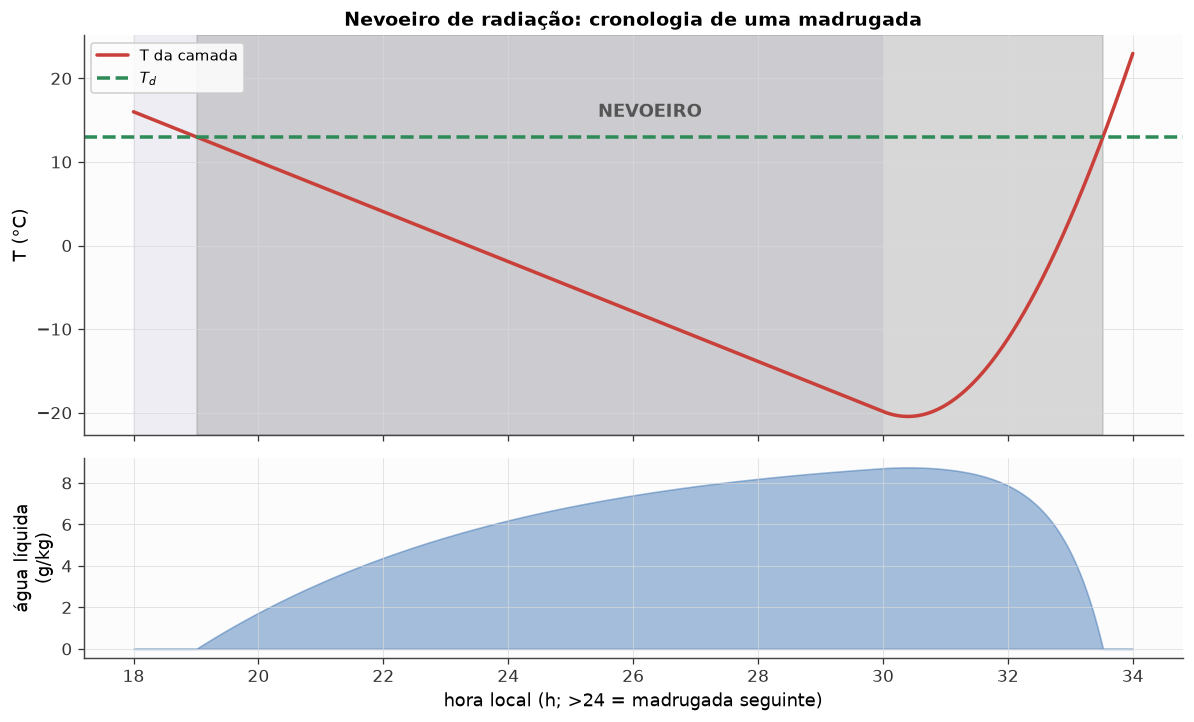

forma às 19.0 h | dissipa às 9.5 h | LWC máx = 8.75 g/kg
estimativa de formação da fórmula do quadro: 19.0 h ✓


In [3]:
dz, F_IR, A = 50.0, 50.0, 0.2
T_ini, Td = 16.0, 13.0                  # anoitecer: 3 K a fechar
P_kPa, eps = 100.0, 0.622
C_cam = rho*Cp*dz

def S_sol(t_h):
    h = t_h % 24
    return np.maximum(0.0, 600.0*np.sin(np.pi*(h - 6)/12))

def dTdt(t_h, T):
    return (-(F_IR) + (1 - A)*S_sol(t_h))/C_cam*3600.0

t = np.linspace(18, 34, 900)            # 18 h até 10 h do dia seguinte
sol = solve_ivp(dTdt, [18, 34], [T_ini], t_eval=t, max_step=0.05)
T_t = sol.y[0]

# água líquida: excesso de r em relação à saturação quando T < Td
r_de = lambda T_C: 1e3*eps*es_kPa(T_C)/(P_kPa - es_kPa(T_C))   # g/kg
r_disp = r_de(Td)                        # vapor disponível fixado no anoitecer
LWC = np.maximum(0.0, r_disp - r_de(T_t))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.5, 6.4), sharex=True,
                               height_ratios=[2, 1])
ax1.axvspan(18, 30, color='#e8e8f0', alpha=0.7, zorder=0)
ax1.plot(t, T_t, color=CORES['vermelho'], label='T da camada')
ax1.axhline(Td, color=CORES['verde'], ls='--', label='$T_d$')
nevoa = LWC > 0
if nevoa.any():
    ax1.axvspan(t[nevoa][0], t[nevoa][-1], color=CORES['cinza'], alpha=0.25)
    ax1.text(0.5*(t[nevoa][0]+t[nevoa][-1]), T_ini - 0.6, 'NEVOEIRO',
             ha='center', fontsize=11, color='#555555', weight='bold')
ax1.set(ylabel='T (°C)', title='Nevoeiro de radiação: cronologia de uma madrugada')
ax1.legend(loc='upper left')
ax2.fill_between(t, LWC, color=CORES['azul'], alpha=0.4)
ax2.set(xlabel='hora local (h; >24 = madrugada seguinte)',
        ylabel='água líquida\n(g/kg)')
fig.tight_layout(); plt.show()

if nevoa.any():
    print(f'forma às {t[nevoa][0]%24:.1f} h | dissipa às {t[nevoa][-1]%24:.1f} h | '
          f'LWC máx = {LWC.max():.2f} g/kg')
t_teo = C_cam*(T_ini - Td)/F_IR/3600
print(f'estimativa de formação da fórmula do quadro: {18 + t_teo:.1f} h ✓')

## Caso 3 — Nuvens fractais: sintetizar e medir

Campos de nuvens reais têm espectro de potência em lei de potência ($E(k) \propto k^{-\beta}$) e bordas fractais. Receita: ruído gaussiano filtrado com $k^{-\beta/2}$ → limiar → campo de nuvens. Depois medimos a dimensão fractal do perímetro por **contagem de caixas** e comparamos com o $D \simeq 1{,}35$ de Lovejoy (satélite).

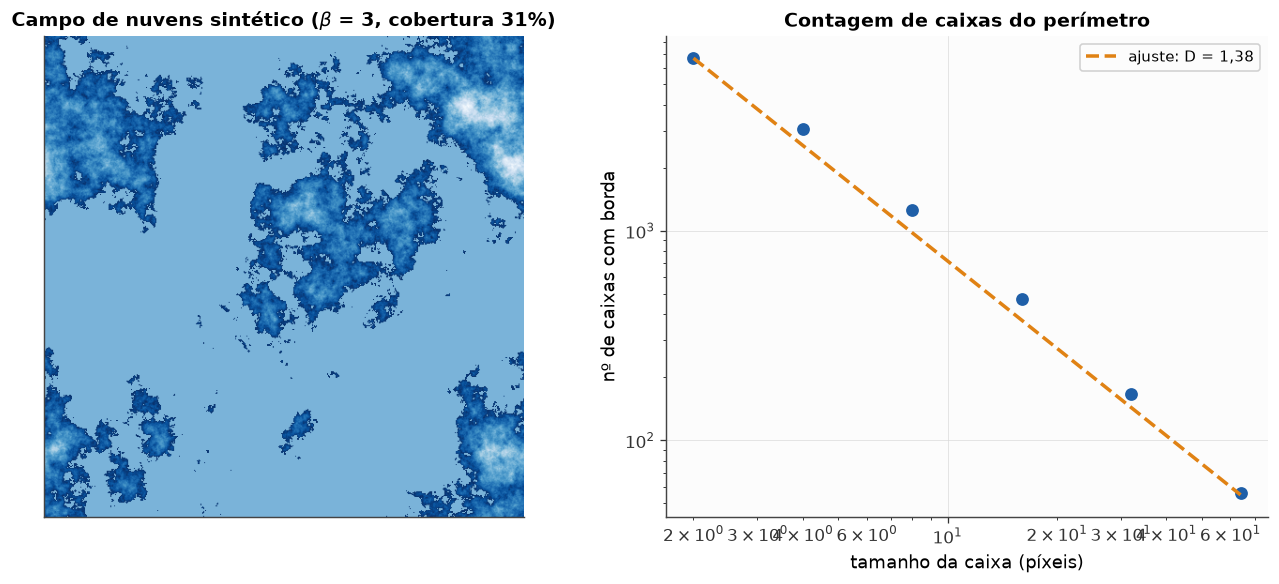

D medido = 1.38  (nuvens reais, Lovejoy: D ≈ 1,35)


In [4]:
rng = np.random.default_rng(6)
Ng = 512
kx = np.fft.fftfreq(Ng)[:, None]; ky = np.fft.fftfreq(Ng)[None, :]
k = np.sqrt(kx**2 + ky**2); k[0, 0] = 1.0
beta = 3.0
campo = np.fft.ifft2(np.fft.fft2(rng.standard_normal((Ng, Ng)))*k**(-beta/2)).real
campo = (campo - campo.mean())/campo.std()
nuvem = campo > 0.5                      # ~30% de cobertura

# perímetro: células de nuvem com algum vizinho de céu claro
viz = (np.roll(nuvem, 1, 0) & np.roll(nuvem, -1, 0) &
       np.roll(nuvem, 1, 1) & np.roll(nuvem, -1, 1))
borda = nuvem & ~viz

def contagem_caixas(mask, tamanhos):
    Ns = []
    for s in tamanhos:
        m = mask[:mask.shape[0]//s*s, :mask.shape[1]//s*s]
        blocos = m.reshape(m.shape[0]//s, s, m.shape[1]//s, s)
        Ns.append(blocos.any(axis=(1, 3)).sum())
    return np.array(Ns)

tams = np.array([2, 4, 8, 16, 32, 64])
Ns = contagem_caixas(borda, tams)
D = -np.polyfit(np.log(tams), np.log(Ns), 1)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 5.2))
ax1.imshow(np.where(nuvem, campo, np.nan), cmap='Blues_r', origin='lower')
ax1.set_facecolor('#7ab3d9')
ax1.set(title=f'Campo de nuvens sintético ($\\beta$ = {beta:.0f}, '
              f'cobertura {100*nuvem.mean():.0f}%)', xticks=[], yticks=[])
ax2.loglog(tams, Ns, 'o', color=CORES['azul'], ms=7)
ax2.loglog(tams, Ns[0]*(tams/tams[0])**(-D), '--', color=CORES['laranja'],
           label=f'ajuste: D = {D:.2f}'.replace('.', ','))
ax2.set(xlabel='tamanho da caixa (píxeis)', ylabel='nº de caixas com borda',
        title='Contagem de caixas do perímetro')
ax2.legend()
fig.tight_layout(); plt.show()
print(f'D medido = {D:.2f}  (nuvens reais, Lovejoy: D ≈ 1,35)')

## Caso 4 — Lendo a organização: ondas e ruas

Dois padrões, duas físicas do Cap. 5:
- **nuvens de onda** (estável): $\lambda = U\,P_{BV} = 2\pi U/N$;
- **ruas de cumulus** (convectivo): $\lambda \simeq 2\text{–}3\,z_i$.

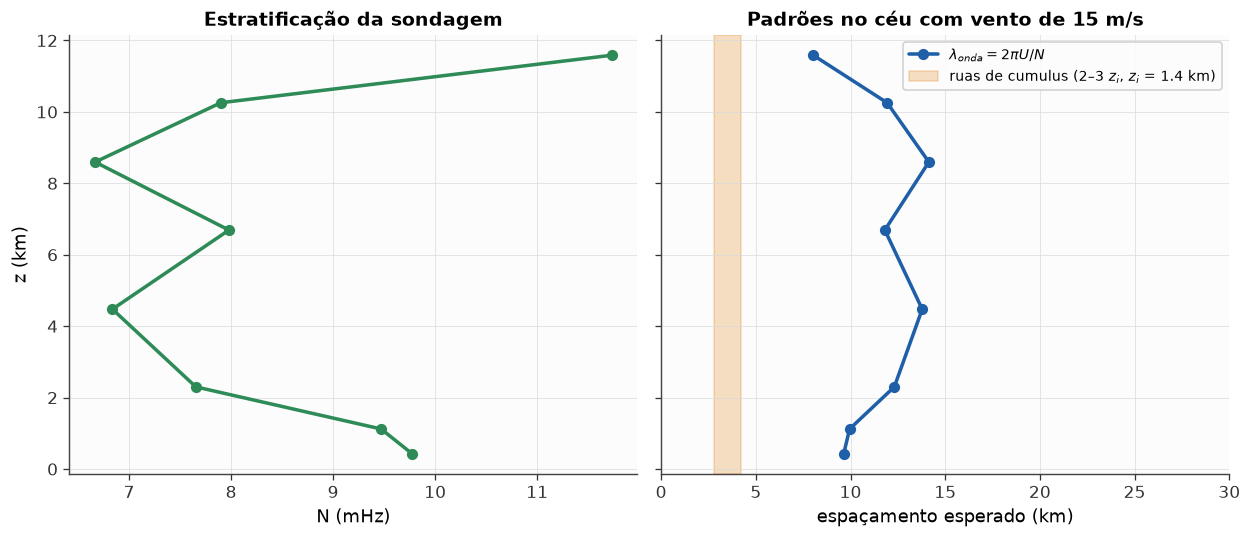

faixas de onda mais finas: 8.0 km na camada de 10.9–12.3 km (a mais estável)
ruas de cumulus esperadas: 2.8–4.2 km — compare com fotos de satélite!


In [5]:
# N(z) camada a camada da sondagem do curso (θv aproximado por θ)
z_km  = np.array([0.08, 0.76, 1.48, 3.12, 5.83, 7.55, 9.64, 10.87, 12.30])
theta = np.array([300.5, 302.5, 304.5, 307.5, 311.5, 315.0, 318.0, 320.5, 327.0])
U_vento = 15.0

zm = 0.5*(z_km[1:] + z_km[:-1])
N2 = g/(0.5*(theta[1:]+theta[:-1]))*np.diff(theta)/np.diff(z_km*1e3)
N = np.sqrt(np.maximum(N2, 0))
lam_onda = np.where(N > 0, 2*np.pi*U_vento/np.maximum(N, 1e-9)/1e3, np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.8), sharey=True)
ax1.plot(N*1e3, zm, 'o-', color=CORES['verde'])
ax1.set(xlabel='N (mHz)', ylabel='z (km)', title='Estratificação da sondagem')
ax2.plot(lam_onda, zm, 'o-', color=CORES['azul'],
         label='$\\lambda_{onda} = 2\\pi U/N$')
zi = 1.4
ax2.axvspan(2*zi, 3*zi, color=CORES['laranja'], alpha=0.25,
            label=f'ruas de cumulus (2–3 $z_i$, $z_i$ = {zi} km)')
ax2.set(xlabel='espaçamento esperado (km)', xlim=(0, 30),
        title=f'Padrões no céu com vento de {U_vento:.0f} m/s')
ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

i_best = np.nanargmin(lam_onda)
print(f'faixas de onda mais finas: {lam_onda[i_best]:.1f} km na camada de '
      f'{z_km[i_best]:.1f}–{z_km[i_best+1]:.1f} km (a mais estável)')
print(f'ruas de cumulus esperadas: {2*zi:.1f}–{3*zi:.1f} km — '
      'compare com fotos de satélite!')

---
## Exercícios numéricos complementares

Enunciados completos (e teóricos T1–T5) nas notas de aula; **soluções em `cap06_solucoes.ipynb`**.

**N1** — No Caso 1, varra a fração de mistura e ache a UR máxima; repita trocando o ar de inverno por um dia de 15 °C (mesma UR de 60 %) e mostre por que o bafo desaparece.

**N2** — No Caso 2, varra $F_{IR}$ de 10 a 70 W/m² (efeito da nebulosidade): trace hora de formação e LWC máximo contra $F_{IR}$, e ache o valor mínimo que ainda produz nevoeiro antes das 6 h.

**N3** — Gere campos com $\beta = 2{,}0, 2{,}5, 3{,}0, 3{,}5, 4{,}0$ e meça $D(\beta)$; para qual $\beta$ o campo tem o $D \approx 1{,}35$ das nuvens reais?

**N4** — No Caso 4, refaça o cálculo para vento de 5 e de 30 m/s e discuta: por que dias de vento forte dão faixas mais espaçadas, e o que limita a visibilidade do padrão?

In [6]:
# N1 — sua solução aqui


In [7]:
# N2 — sua solução aqui


In [8]:
# N3 — sua solução aqui


In [9]:
# N4 — sua solução aqui


---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*